# Flambeau Outage Timing Recommendation
Recommending the best 2-week window in 2027 for a planned Flambeau
outage, based on 10 years (2016–2025) of historical MISO LMP data
and Flambeau generation data.

## 1. Data Collection & Preparation
Historical LMP data was pulled directly from MISO's public Day-Ahead
ExPost LMP reports (monthly zip archives for 2016–2022, daily CSVs
for 2023–2025), filtered to the DPC.FLAMBEAU node's LMP value, and
reshaped from 24 hourly columns into a clean hourly time series.
Flambeau's generation data (~4-day cadence) was cleaned by dropping
leading missing readings and interpolating gaps between values.

In [1]:
import pandas as pd
from pathlib import Path
from datetime import date, timedelta

In [2]:
lmp_dir = Path("../data/raw/lmp")
files = sorted(lmp_dir.glob("*_da_expost_lmp.csv"))
print(len(files), "files found")

3653 files found


In [3]:
def load_flambeau_lmp(path):
    df = pd.read_csv(path, skiprows=4)
    row = df[(df["Node"] == "DPC.FLAMBEAU") & (df["Value"] == "LMP")]
    if row.empty:
        return None

    file_date = pd.to_datetime(path.name[:8], format="%Y%m%d")

    he_cols = [c for c in df.columns if c.startswith("HE ")]
    long = row.melt(id_vars=["Node", "Type", "Value"], value_vars=he_cols, var_name="HE", value_name="LMP")
    long["hour"] = long["HE"].str.replace("HE ", "").astype(int)
    long["timestamp"] = file_date + pd.to_timedelta(long["hour"] - 1, unit="h")
    return long[["timestamp", "LMP"]]

In [4]:
cache_path = Path("../data/processed/lmp_hourly.csv")

if cache_path.exists():
    lmp_df = pd.read_csv(cache_path, parse_dates=["timestamp"])
else:
    all_lmp = []
    for f in files:
        result = load_flambeau_lmp(f)
        if result is not None:
            all_lmp.append(result)
        else:
            print("missing Flambeau row:", f.name)
    lmp_df = pd.concat(all_lmp, ignore_index=True).sort_values("timestamp").reset_index(drop=True)
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    lmp_df.to_csv(cache_path, index=False)

In [6]:
gen_df = pd.read_csv("../data/raw/flambeau_gen.csv", na_values=["undefined"])
gen_df["Timestamp"] = pd.to_datetime(gen_df["Timestamp"])
gen_df = gen_df.rename(columns={"Flambeau (MW)": "MW"})
gen_df = gen_df.sort_values("Timestamp").reset_index(drop=True)

In [7]:
# Drop rows with missing MW values
first_valid = gen_df["MW"].first_valid_index()
gen_df = gen_df.loc[first_valid:].reset_index(drop=True)

# Fill any remaining internal gaps by interpolating between known points
gen_df["MW"] = gen_df["MW"].interpolate(method="linear")

## 2. Merging LMP and Generation Data
LMP (hourly) and generation (~4-day) were reconciled by treating
generation as instantaneous point readings and linearly interpolating
between them to estimate output for every hour — chosen because
readings arrive at a consistent time each cycle, resembling a periodic
sensor reading rather than an interval average. Hourly revenue =
interpolated MW × that hour's real LMP.

In [8]:
# Interpolate

gen_df["Timestamp"] = gen_df["Timestamp"].dt.tz_convert("Etc/GMT+5").dt.tz_localize(None)
gen_indexed = gen_df.set_index("Timestamp")[["MW"]]
full_hours = pd.date_range(lmp_df["timestamp"].min(), lmp_df["timestamp"].max(), freq="h")

gen_hourly = gen_indexed.reindex(gen_indexed.index.union(full_hours))
gen_hourly["MW"] = gen_hourly["MW"].interpolate(method="time")
gen_hourly = gen_hourly.reindex(full_hours).rename_axis("timestamp").reset_index()

merged_interp = lmp_df.merge(gen_hourly, on="timestamp", how="inner").dropna(subset=["MW"])
merged_interp["revenue"] = merged_interp["MW"] * merged_interp["LMP"]

merged_interp["date"] = merged_interp["timestamp"].dt.date
daily = merged_interp.groupby("date")["revenue"].sum().reset_index()
daily["date"] = pd.to_datetime(daily["date"])

daily["iso_year"] = daily["date"].dt.isocalendar().year
daily["iso_week"] = daily["date"].dt.isocalendar().week

## 3. Exploratory Analysis

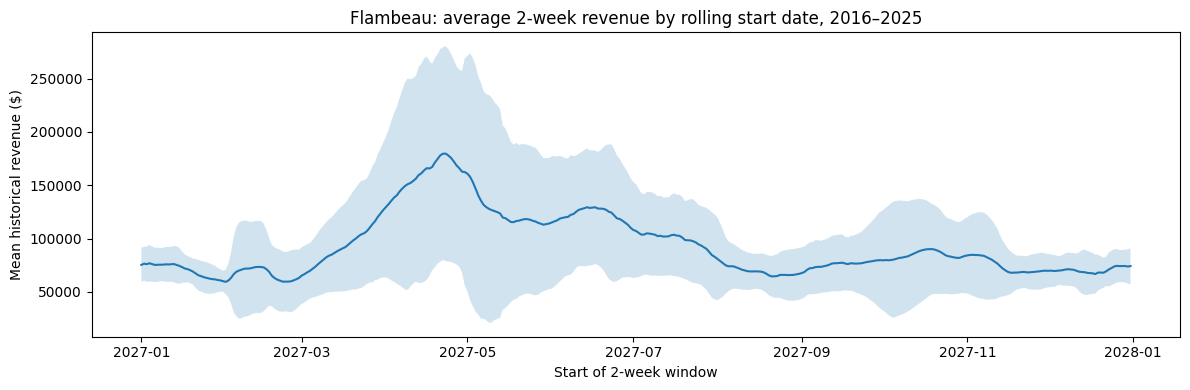

### Learned From EDA
Based on the findings of this time-series chart, it can be said that revenue generated by the dam is consistently low in the winter months and early fall. Note that some months have more predictable variance in revenue, specifically the winter months. This is likely due to a lack of overall precipitation and a lower demand for power. Inversely, revenue is much higher in mid-to-late spring, as well as its variance from the mean, most likely caused by snowmelt and an increase in overall rainfall. The variance is much higher here as well, likely due to fluctuating weather conditions, since LMP is typically less volitile in the spring and fall months.

## 4. Recommended Outage Windows
Rather than checking a fixed set of 26 two-week blocks, I evaluated every possible 2-week interval across all 10 years, using the mean historical revenue as the expecteed oppurtunity cost and the year-to-year range as the uncertainty estimate. My first attempt at this only evaluated non-overlapping 2-week blocks starting from day 1 of the data, but that led to non-optimal results because only 26 intervals were evaluated. Switching over to a rolling approach yielded a much smoother, less noisy revenue curve. 

In [9]:
# Check every possible 2 week interval
daily_full = daily.set_index("date").sort_index()

trailing_sum = daily_full["revenue"].rolling(window=14).sum()
daily_full["window_revenue"] = trailing_sum.shift(-13)  # sums date..date+13, not date-13..date
daily_full = daily_full.dropna(subset=["window_revenue"])

daily_full["month_day"] = daily_full.index.strftime("%m-%d")

window_curve = (
    daily_full.groupby("month_day")["window_revenue"]
    .agg(["mean", "std", "min", "max", "count"])
    .reset_index()
    .sort_values("mean")
)

full_years = window_curve["count"].max()
candidates = window_curve[window_curve["count"] >= full_years - 1].head(3)

In [10]:
def month_day_to_2027(month_day):
    month, day = map(int, month_day.split("-"))
    if month == 2 and day == 29:    # 2027 isn't a leap year
        day = 28
    start = date(2027, month, day)
    end = start + timedelta(days=13)
    return start, end

top3 = window_curve[window_curve["count"] >= window_curve["count"].max() - 1].sort_values("mean").head(3)

for _, row in top3.iterrows():
    start, end = month_day_to_2027(row["month_day"])
    print(f"{start} to {end}: mean lost revenue ${row['mean']:,.0f} "
          f"(range ${row['min']:,.0f}-${row['max']:,.0f}, n={int(row['count'])} years)")

2027-02-01 to 2027-02-14: mean lost revenue $59,284 (range $47,411-$76,326, n=10 years)
2027-02-24 to 2027-03-09: mean lost revenue $59,532 (range $30,301-$133,513, n=10 years)
2027-02-22 to 2027-03-07: mean lost revenue $59,543 (range $31,352-$134,051, n=10 years)


## 5. Assumptions & Limitations
- Generation readings are assumed instantaneous, not interval averages
  (undocumented in the source data)
- Assumes historical seasonal patterns repeat into 2027
- 2016–2025 used as the representative sample
- A natural next step would be testing sensitivity to the
  instantaneous-vs-average assumption, and incorporating a long-term
  price trend rather than treating all 10 years as equally
  representative